In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

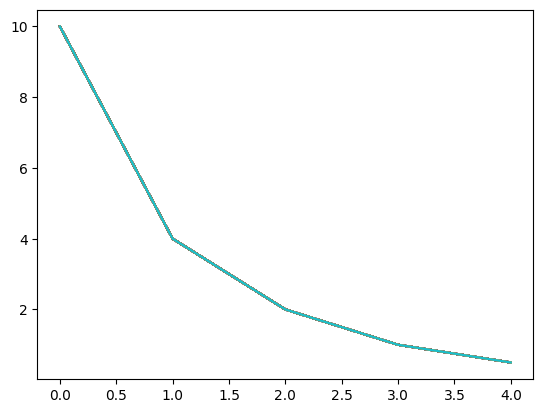

In [2]:
N_p = 100 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

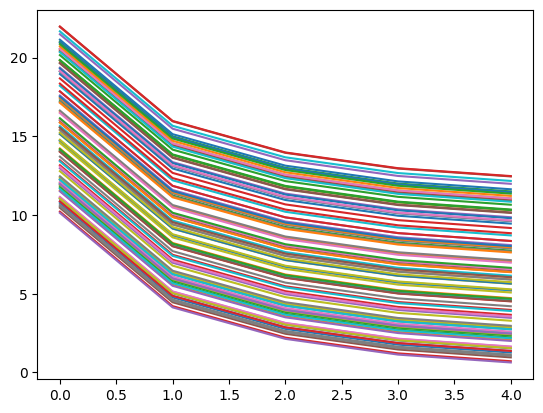

In [3]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

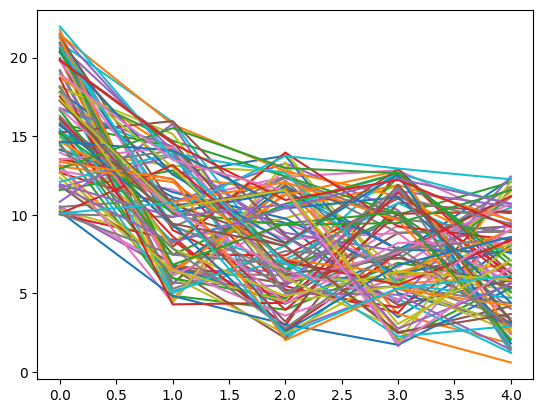

In [4]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [5]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   500       Method:               REML     
No. Groups:         100       Scale:                0.0000   
Min. group size:    5         Log-Likelihood:       3620.2052
Max. group size:    5         Converged:            Yes      
Mean group size:    5.0                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   15.636     0.157       99.806 0.000 15.329 15.943
Week[T.T1]  -6.000     0.000 -3288246.267 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -4384328.356 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -4932369.400 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -5206389.923 0.000 -9.500 -9.500
Patient Var  2.454 13519.006                                 
=============================================================

"""

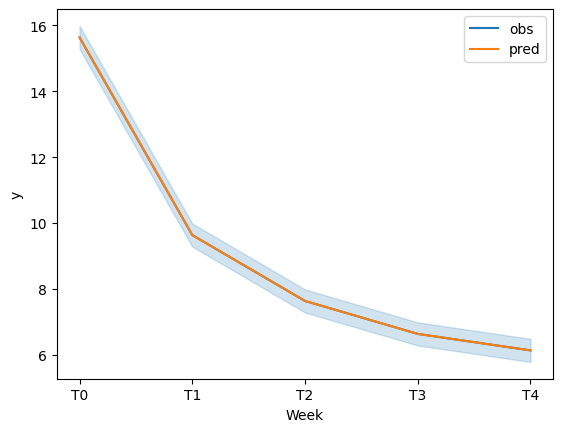

In [6]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [7]:
kill = np.random.randint(low=0, high=500, size=200)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   331       Method:               REML     
No. Groups:         99        Scale:                0.0000   
Min. group size:    1         Log-Likelihood:       1810.1019
Max. group size:    5         Converged:            Yes      
Mean group size:    3.3                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   15.585     0.192       81.200 0.000 15.209 15.961
Week[T.T1]  -6.000     0.000 -1222316.177 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -1665535.803 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -1861384.527 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -1913547.386 0.000 -9.500 -9.500
Patient Var  3.647 12827.821                                 
=============================================================

"""

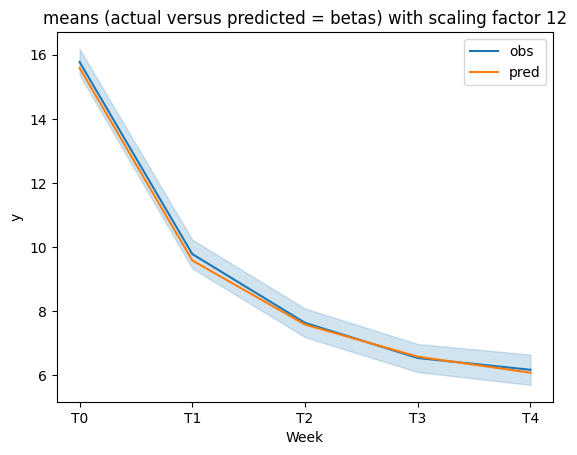

In [8]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

Additive differences between subjs: should make sense to use the intercept (fitted lines will be additively different by subj_intercept (re) value).

Multiplicative:

In [9]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient').fit()

model.summary()

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
========================================================
Model:            MixedLM Dependent Variable: y         
No. Observations: 500     Method:             REML      
No. Groups:       100     Scale:              11.4138   
Min. group size:  5       Log-Likelihood:     -1325.7228
Max. group size:  5       Converged:          Yes       
Mean group size:  5.0                                   
--------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
--------------------------------------------------------
Intercept   16.262    0.345  47.178 0.000  15.586 16.937
Week[T.T1]  -6.363    0.478 -13.319 0.000  -7.300 -5.427
Week[T.T2]  -8.242    0.478 -17.250 0.000  -9.178 -7.306
Week[T.T3]  -8.507    0.478 -17.805 0.000  -9.444 -7.571
Week[T.T4]  -9.531    0.478 -19.948 0.000 -10.467 -8.595
Patient Var  0.467    0.139                             
========================================================

"""

In [10]:
df_mult_b = pd.DataFrame(model.fe_params.to_numpy(), columns = ['y_pred'])
timepoints = df_mult.Week.unique()
df_mult_b['Week'] = timepoints
df_mult_b['se'] = model.bse_fe.to_numpy() # se of betas (fixed effects se)

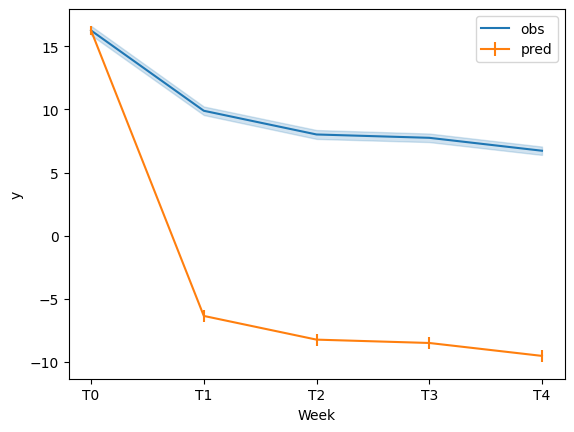

In [15]:
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.errorbar(data = df_mult_b, x='Week', y='y_pred', yerr = 'se', label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [12]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient').fit()

model.summary()


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
========================================================
Model:             MixedLM Dependent Variable: y        
No. Observations:  331     Method:             REML     
No. Groups:        99      Scale:              11.9385  
Min. group size:   1       Log-Likelihood:     -877.2531
Max. group size:   5       Converged:          Yes      
Mean group size:   3.3                                  
--------------------------------------------------------
            Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
--------------------------------------------------------
Intercept   16.049    0.407  39.407 0.000  15.250 16.847
Week[T.T1]  -6.060    0.599 -10.123 0.000  -7.234 -4.887
Week[T.T2]  -7.894    0.589 -13.407 0.000  -9.049 -6.740
Week[T.T3]  -8.451    0.583 -14.505 0.000  -9.593 -7.309
Week[T.T4]  -9.237    0.599 -15.420 0.000 -10.411 -8.063
Patient Var  0.000    0.190                             
========================================================

"""

In [13]:
# df of just the predicted means

df_mult_kill_b = pd.DataFrame(model.fe_params.to_numpy(), columns = ['y_pred'])
timepoints = df_mult_kill.Week.unique()
df_mult_kill_b['Week'] = timepoints
df_mult_kill_b['se'] = model.bse_fe.to_numpy() # se of betas (fixed effects se)

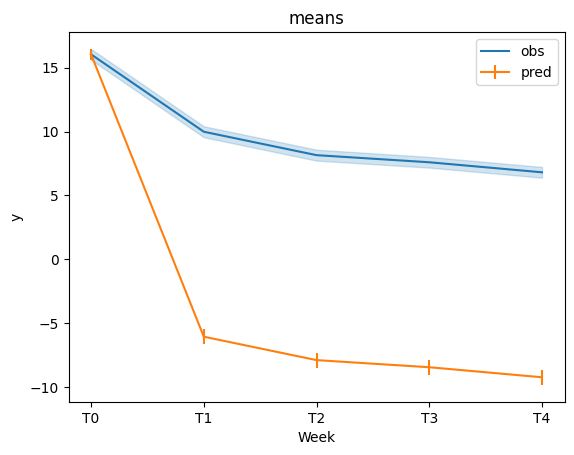

In [14]:
sns.lineplot(data=df_mult_kill, x='Week', y='y', errorbar='se', label = 'obs')

plt.errorbar(data = df_mult_kill_b, x='Week', y='y_pred', yerr = 'se', label = 'pred')
plt.legend()
plt.title(f"means")
plt.show()